# Synent Technologies – Task 9
# End-to-End Data Science Project: Telco Customer Churn Prediction

## Objective

Build a complete end-to-end Data Science project following the Synent Technologies Task 9 requirements:

1. Data collection
2. Data cleaning
3. Exploratory Data Analysis (EDA)
4. Model building
5. Model evaluation
6. Model saving
7. Streamlit application preparation
8. Deployment preparation

## Problem Statement

Customer churn is an important business problem for subscription-based companies.
The goal of this project is to build a machine learning model that predicts whether
a telecom customer is likely to churn based on customer and service information.

## Dataset

Dataset: Telco Customer Churn

Source: Kaggle – Telco Customer Churn

Target variable:
- `Churn = Yes` → customer churned
- `Churn = No` → customer stayed

Download the CSV from Kaggle and place it next to the notebook (VS Code local file).

## 1. Import Libraries

In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import joblib

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Create Project Folders

In [2]:
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("model", exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


## 3. Locate the Dataset (VS Code local file)

Download `WA_Fn-UseC_-Telco-Customer-Churn.csv` from the Kaggle Telco Customer Churn dataset.

Then run the next cell to verify the CSV is found locally.

In [3]:
# VS Code : pas d'upload, le CSV est déjà en local à côté du notebook
import os
csv_filename = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

if os.path.exists(csv_filename):
    print(f"Fichier trouvé : {csv_filename}")
else:
    # cherche aussi dans data/ et le dossier courant
    print(f"Fichier non trouvé : {csv_filename}")
    print("Contenu du dossier courant :")
    for f in os.listdir("."):
        print("-", f)
    raise FileNotFoundError(
        f"Placez {csv_filename} à côté du notebook ou mettez à jour csv_filename."
    )

Fichier trouvé : WA_Fn-UseC_-Telco-Customer-Churn.csv


## 4. Load the Dataset

In [4]:
# VS Code : charge le CSV depuis le dossier local
from pathlib import Path

# Réutilise csv_filename défini dans la cellule précédente si possible
candidate = globals().get("csv_filename", "WA_Fn-UseC_-Telco-Customer-Churn.csv")

possible_paths = [
    Path(candidate),
    Path("data") / Path(candidate).name,
    Path("../data") / Path(candidate).name,
    Path.cwd() / Path(candidate).name,
    Path.cwd() / "data" / Path(candidate).name,
]

csv_path = next((str(p) for p in possible_paths if p.exists()), None)

if csv_path is None:
    # fallback : cherche n'importe quel CSV dans ., data/, ../data/
    search_dirs = [Path("."), Path("data"), Path("../data")]
    csv_files = []
    for d in search_dirs:
        if d.exists():
            csv_files += sorted(d.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(
            "Aucun CSV trouvé. Placez 'WA_Fn-UseC_-Telco-Customer-Churn.csv' "
            "à côté du notebook ou dans data/."
        )
    csv_path = str(csv_files[0])

df = pd.read_csv(csv_path)

print("Dataset loaded successfully!")
print("File:", csv_path)


Dataset loaded successfully!
File: WA_Fn-UseC_-Telco-Customer-Churn.csv


## 5. First Look at the Dataset

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


In [7]:
print("Columns:")
for column in df.columns:
    print("-", column)

Columns:
- customerID
- gender
- SeniorCitizen
- Partner
- Dependents
- tenure
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod
- MonthlyCharges
- TotalCharges
- Churn


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 6. Data Quality Check

In [9]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df) * 100).round(2)
}).sort_values("Missing Values", ascending=False)

display(missing_table)

,Missing Values,Missing Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [10]:
print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 0


In [11]:
if "customerID" in df.columns:
    print("Duplicated customer IDs:", df["customerID"].duplicated().sum())

Duplicated customer IDs: 0


## 7. Data Cleaning

In [12]:
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"],
        errors="coerce"
    )

before_duplicates = len(df)
df = df.drop_duplicates().copy()
after_duplicates = len(df)

print("Duplicates removed:", before_duplicates - after_duplicates)

if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

print("Data cleaning step completed.")

Duplicates removed: 0
Data cleaning step completed.


In [13]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [14]:
if "TotalCharges" in df.columns:
    missing_total_charges = df[df["TotalCharges"].isnull()]
    print("Rows with missing TotalCharges:", len(missing_total_charges))
    display(missing_total_charges.head())

Rows with missing TotalCharges: 11


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No


In [15]:
# Fill numeric missing values.
# This is also repeated safely later inside the ML pipeline.
numeric_columns_before_model = df.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numeric_columns_before_model:
    if df[column].isnull().any():
        df[column] = df[column].fillna(df[column].median())

print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## 8. Exploratory Data Analysis (EDA)

EDA is used to understand the target variable and important customer characteristics
before model building.

Churn
No     5174
Yes    1869
Name: count, dtype: int64


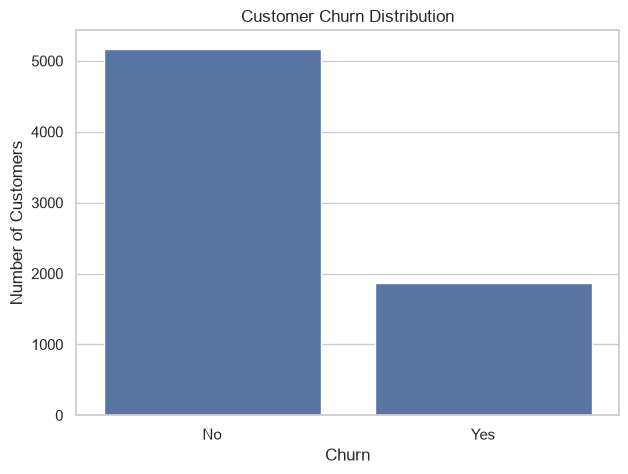

In [16]:
churn_counts = df["Churn"].value_counts()

print(churn_counts)

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.savefig(
    "outputs/figures/churn_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [17]:
churn_percentages = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Churn percentage:")
print(churn_percentages)

Churn percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


### Numerical Variables

In [18]:
numeric_columns = [
    column for column in [
        "SeniorCitizen",
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
    if column in df.columns
]

display(df[numeric_columns].describe())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


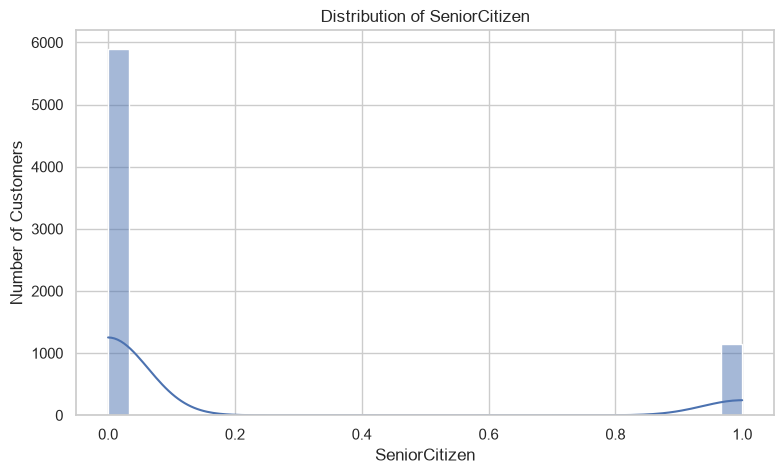

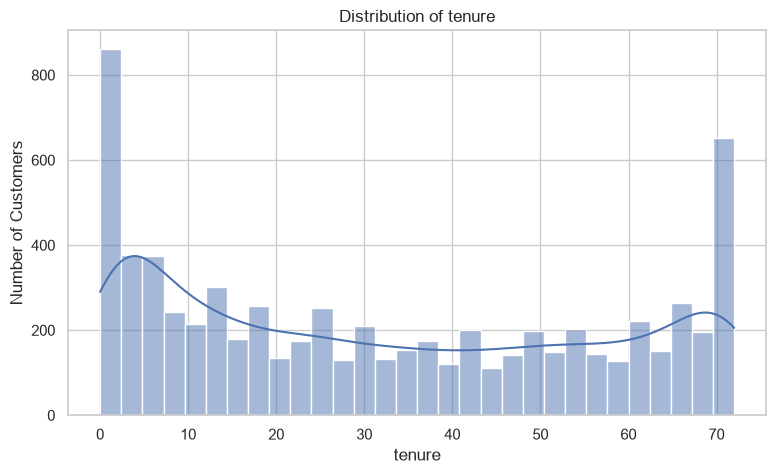

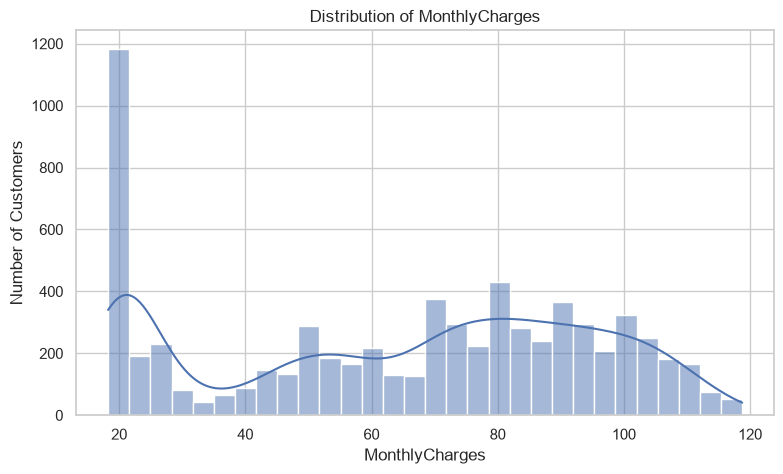

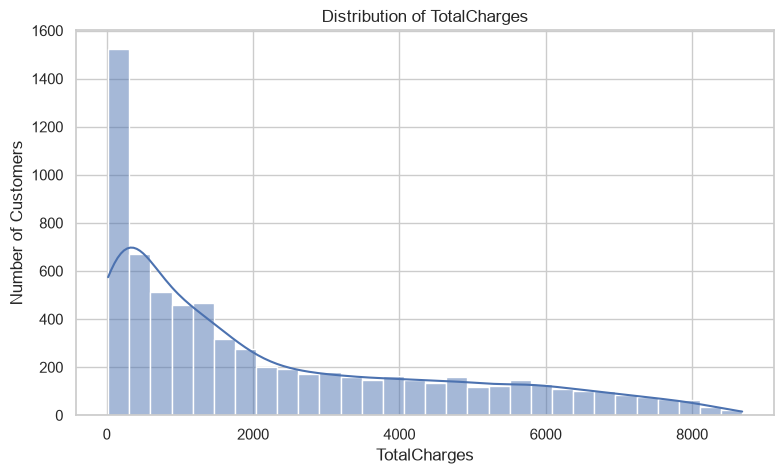

In [19]:
for column in numeric_columns:
    plt.figure(figsize=(9, 5))

    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")

    filename = (
        column.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
    )

    plt.savefig(
        f"outputs/figures/{filename}_distribution.png",
        bbox_inches="tight"
    )

    plt.show()

### Churn vs Tenure

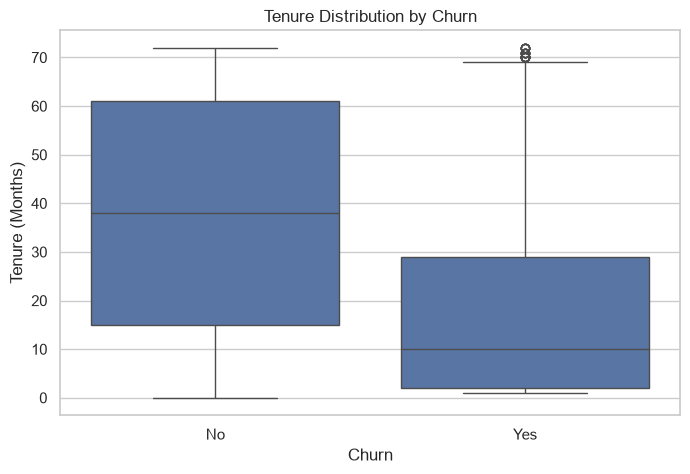

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.savefig(
    "outputs/figures/tenure_by_churn.png",
    bbox_inches="tight"
)

plt.show()

### Churn vs Monthly Charges

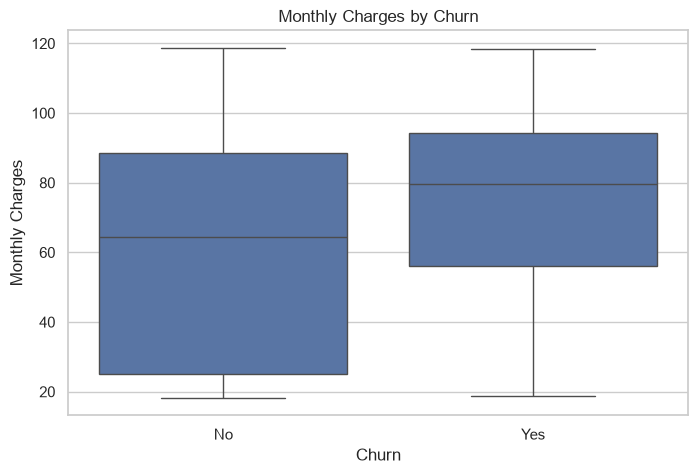

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.savefig(
    "outputs/figures/monthly_charges_by_churn.png",
    bbox_inches="tight"
)

plt.show()

### Churn by Contract Type

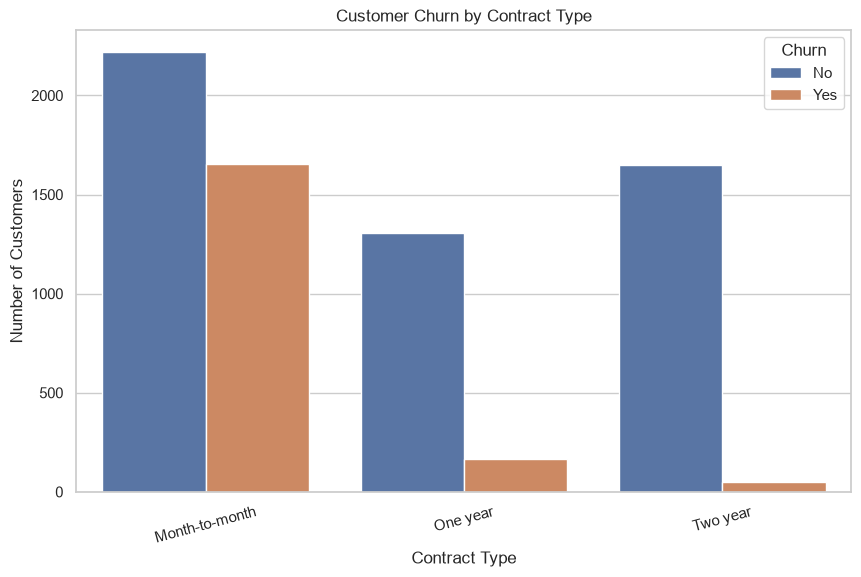

In [22]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.savefig(
    "outputs/figures/churn_by_contract.png",
    bbox_inches="tight"
)

plt.show()

### Churn by Internet Service

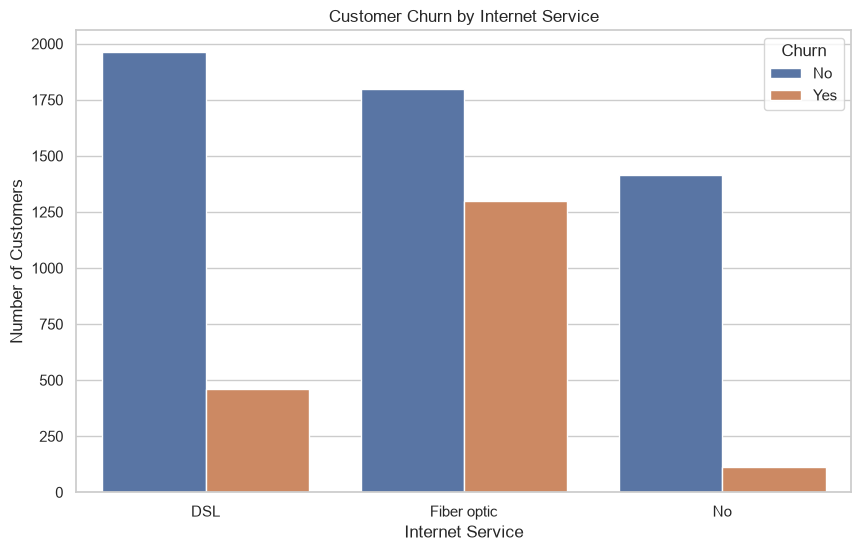

In [23]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.savefig(
    "outputs/figures/churn_by_internet_service.png",
    bbox_inches="tight"
)

plt.show()

### Correlation Analysis

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102652
tenure,0.016567,1.000000,0.247900,0.825464
MonthlyCharges,0.220173,0.247900,1.000000,0.650864
TotalCharges,0.102652,0.825464,0.650864,1.000000


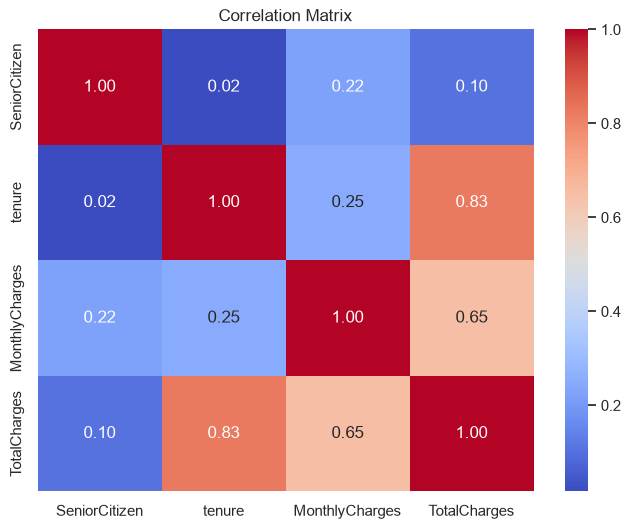

In [24]:
available_numeric = [
    column for column in [
        "SeniorCitizen",
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
    if column in df.columns
]

correlation_matrix = df[available_numeric].corr()

display(correlation_matrix)

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.savefig(
    "outputs/figures/correlation_matrix.png",
    bbox_inches="tight"
)

plt.show()

## 9. Prepare Data for Machine Learning

In [25]:
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

X = df.drop(columns=["Churn"]).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (7043, 19)
y shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


## 10. Train/Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5634, 19)
Testing set: (1409, 19)


## 11. Build the Preprocessing Pipeline

In [27]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [28]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


## 12. Build the Machine Learning Model

In [29]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Model pipeline created successfully!")

Model pipeline created successfully!


## 13. Train the Model

In [30]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## 14. Make Predictions

In [31]:
y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


## 15. Evaluate the Model

We report several classification metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC

In [32]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_probability)

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

metrics_df["Score"] = metrics_df["Score"].round(4)

display(metrics_df)

,Metric,Score
0,Accuracy,0.8055
1,Precision,0.6572
2,Recall,0.5588
3,F1 Score,0.6040
4,ROC AUC,0.8419


In [33]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Stayed", "Churned"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1035
     Churned       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### Confusion Matrix

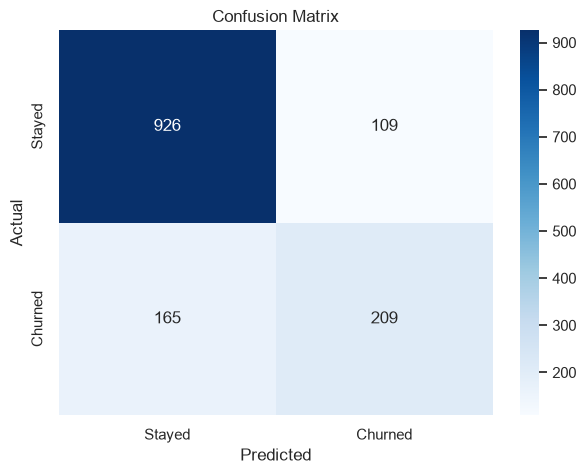

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "outputs/figures/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

### ROC Curve

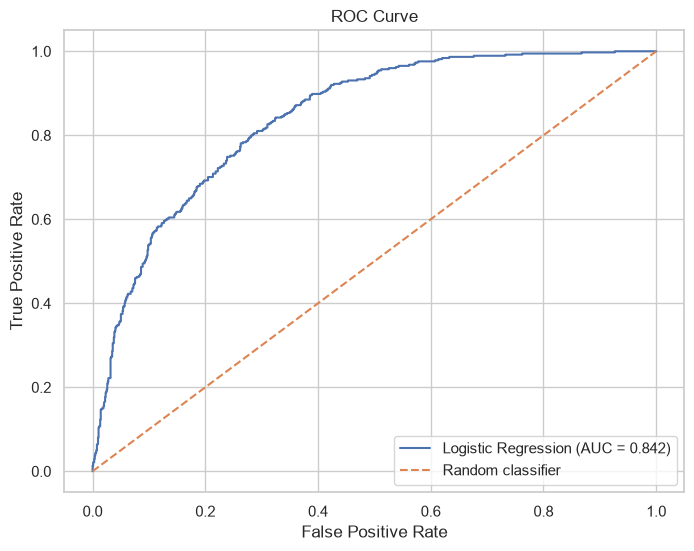

In [35]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.savefig(
    "outputs/figures/roc_curve.png",
    bbox_inches="tight"
)

plt.show()

## 16. Example Prediction on a Test Customer

In [36]:
example_index = X_test.index[0]

example_customer = X_test.loc[[example_index]]
actual_value = y_test.loc[example_index]
predicted_value = model.predict(example_customer)[0]
predicted_probability = model.predict_proba(example_customer)[0, 1]

print("Actual:", "Churn" if actual_value == 1 else "Stay")
print("Predicted:", "Churn" if predicted_value == 1 else "Stay")
print(f"Predicted churn probability: {predicted_probability:.2%}")

Actual: Stay
Predicted: Stay
Predicted churn probability: 4.52%


## 17. Save the Trained Model

In [37]:
model_path = "model/churn_model.joblib"

joblib.dump(
    model,
    model_path
)

print("Model saved to:")
print(model_path)

Model saved to:
model/churn_model.joblib


In [38]:
loaded_model = joblib.load(model_path)

test_predictions = loaded_model.predict(
    X_test.head(5)
)

print("Model reload test successful!")
print("Sample predictions:", test_predictions)

Model reload test successful!
Sample predictions: [0 1 0 0 0]


## 18. Save Evaluation Results

In [39]:
metrics_path = "outputs/model_metrics.csv"

metrics_df.to_csv(
    metrics_path,
    index=False
)

print("Metrics saved to:")
print(metrics_path)

Metrics saved to:
outputs/model_metrics.csv


## 19. Save Metadata for Streamlit

In [40]:
metadata = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "feature_columns": X.columns.tolist(),
    "target_mapping": {
        "No": 0,
        "Yes": 1
    },
    "categories": {}
}

for column in categorical_features:
    values = (
        X[column]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )
    metadata["categories"][column] = sorted(values)

metadata_path = "model/model_metadata.json"

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Metadata saved to:")
print(metadata_path)

Metadata saved to:
model/model_metadata.json


## 20. Create the Streamlit Application

This cell generates `app.py`.

The application:
- loads the saved machine learning pipeline
- displays user input fields
- creates a DataFrame with the same feature names used during training
- predicts churn
- displays the prediction and churn probability

In [41]:
app_code = r'''
import json

import joblib
import pandas as pd
import streamlit as st


MODEL_PATH = "model/churn_model.joblib"
METADATA_PATH = "model/model_metadata.json"


@st.cache_resource
def load_model():
    return joblib.load(MODEL_PATH)


@st.cache_data
def load_metadata():
    with open(METADATA_PATH, "r", encoding="utf-8") as file:
        return json.load(file)


model = load_model()
metadata = load_metadata()

st.set_page_config(
    page_title="Telco Churn Prediction",
    page_icon="📊",
    layout="centered"
)

st.title("📊 Telco Customer Churn Prediction")

st.write(
    "Enter customer information to estimate the probability "
    "that the customer will churn."
)

st.markdown("---")

input_data = {}

for column in metadata["feature_columns"]:

    if column in metadata["numeric_features"]:

        if column == "SeniorCitizen":
            input_data[column] = st.selectbox(
                "Senior Citizen",
                [0, 1]
            )

        elif column == "tenure":
            input_data[column] = st.number_input(
                "Tenure (Months)",
                min_value=0,
                max_value=100,
                value=12,
                step=1
            )

        elif column == "MonthlyCharges":
            input_data[column] = st.number_input(
                "Monthly Charges",
                min_value=0.0,
                value=50.0,
                step=1.0
            )

        elif column == "TotalCharges":
            input_data[column] = st.number_input(
                "Total Charges",
                min_value=0.0,
                value=500.0,
                step=10.0
            )

        else:
            input_data[column] = st.number_input(
                column,
                value=0.0
            )

    else:
        options = metadata["categories"].get(column, [])

        input_data[column] = st.selectbox(
            column.replace("_", " "),
            options
        )


st.markdown("---")


if st.button(
    "🔮 Predict Churn",
    use_container_width=True
):

    input_df = pd.DataFrame([input_data])

    prediction = model.predict(input_df)[0]
    churn_probability = model.predict_proba(input_df)[0][1]

    if prediction == 1:
        st.error(
            f"⚠️ High churn risk — probability: "
            f"{churn_probability:.2%}"
        )
        st.write(
            "The model predicts that this customer is likely to churn."
        )
    else:
        st.success(
            f"✅ Low churn risk — probability: "
            f"{1 - churn_probability:.2%}"
        )
        st.write(
            "The model predicts that this customer is likely to stay."
        )

    st.progress(float(churn_probability))

    st.caption(
        "This prediction is an estimate produced by the machine learning model "
        "and is not a guarantee of future customer behavior."
    )
'''

app_path = "app.py"

with open(
    app_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(app_code)

print("Streamlit app created:")
print(app_path)

Streamlit app created:
app.py


## 21. Create requirements.txt

In [42]:
requirements = "\n".join([
    "pandas==2.3.3",
    "numpy==2.4.2",
    "scikit-learn==1.9.1",
    "matplotlib==3.11.2",
    "seaborn==0.13.2",
    "joblib==1.6.0",
    "streamlit==1.64.0"
]) + "\n"

requirements_path = "requirements.txt"

with open(
    requirements_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(requirements)

print("requirements.txt created:")
print(requirements_path)

requirements.txt created:
requirements.txt


## 22. Create a README.md Template

In [43]:
readme = f'''# Synent Task 9 – Telco Customer Churn Prediction

## Project Objective

This project is an end-to-end Data Science application developed as part of
the Synent Technologies Data Science Internship Program.

The goal is to predict whether a telecom customer is likely to churn using
customer, service, contract, and billing information.

## Dataset

**Dataset:** Telco Customer Churn  
**Source:** Kaggle – Telco Customer Churn

The dataset contains customer information such as:
- demographic information
- tenure
- subscribed services
- contract type
- payment method
- monthly charges
- total charges
- churn status

## Workflow

1. Data collection
2. Data cleaning
3. Exploratory Data Analysis (EDA)
4. Feature preprocessing
5. Train/test split
6. Logistic Regression model
7. Model evaluation
8. Model saving
9. Streamlit application
10. Deployment

## Model Evaluation

The model was evaluated using:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC

## Results

Metrics from this run (outputs/model_metrics.csv):
'''

try:
    metrics_table = metrics_df.to_markdown(index=False)
except Exception:
    metrics_table = metrics_df.to_string(index=False)

readme = readme + metrics_table + "\n"

readme += '''
## Application

The Streamlit application allows a user to enter customer information
and receive a churn prediction together with an estimated probability.

## Project Structure

```text
synent-task9-telcochurn-ahmed/
├── data/
├── notebooks/
├── model/
├── outputs/
├── app.py
├── requirements.txt
└── README.md
```

## Author

Ahmed Amin Bejaoui
'''

readme_path = "README.md"

with open(
    readme_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(readme)

print("README.md created:")
print(readme_path)

README.md created:
README.md


## 23. Final Project Verification

In [44]:
files_to_check = [
    "model/churn_model.joblib",
    "model/model_metadata.json",
    "app.py",
    "requirements.txt",
    "README.md",
    "outputs/model_metrics.csv"
]

for path in files_to_check:
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"{status:8} {path}")

OK       model/churn_model.joblib
OK       model/model_metadata.json
OK       app.py
OK       requirements.txt
OK       README.md
OK       outputs/model_metrics.csv


## 24. Key Insights (Results from this run)

Dataset: 7043 rows, 21 columns. After cleaning: 7043 rows (0 duplicates), 11 missing TotalCharges filled with median, customerID removed.

1. Churn rate: 26.54% churned (1869 Yes) vs 73.46% stayed (5174 No). Binary classification problem.

2. Tenure / MonthlyCharges: stayed median tenure 38 months vs churned 10 months (means 37.57 vs 17.98). Stayed median MonthlyCharges 64.43 vs churned 79.65 (means 61.27 vs 74.44). Churned customers are newer with higher monthly bills in this dataset.

3. Contract: Month-to-month churn 42.71%, One year 11.27%, Two year 2.83%. Month-to-month is the highest-risk group observed.

4. InternetService: Fiber optic churn 41.89%, DSL 18.96%, No internet service 7.40%. Fiber optic shows the highest churn rate observed.

5. Model (LogisticRegression, 80/20 stratified, random_state=42): Accuracy 0.8055, Precision 0.6572, Recall 0.5588, F1 0.6040, ROC AUC 0.8419. Good ranking ability (AUC 0.84) but recall ~0.56 means ~44% of real churners are missed.

Correlations: tenure-TotalCharges 0.83, MonthlyCharges-TotalCharges 0.65, tenure-MonthlyCharges 0.25.

### Important

The results describe patterns observed in this dataset.
Correlation and group differences do not automatically prove causation.

## 25. Synent Task 9 Submission Checklist

### Data Science
- [x] Data collection
- [x] Data cleaning
- [x] EDA
- [x] Model building
- [x] Model evaluation

### Application
- [x] User input
- [x] Prediction output
- [x] Streamlit app generated

### Submission
- [ ] Public GitHub repository
- [ ] README.md
- [ ] Dataset or dataset link
- [ ] Demonstration video (1–3 minutes)
- [ ] LinkedIn project post
- [ ] Official Synent submission form